In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive
from matplotlib.widgets import Slider
from weylchamber import WeylChamber, c1c2c3

# !pip install ipympl

In [2]:
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive

H = ZZ_ParallelDrive(np.pi / 2, 0, 0, 0, 0)
U = H.to_unitary()
c1c2c3(U)

(0.5, 0.0, 0.0)

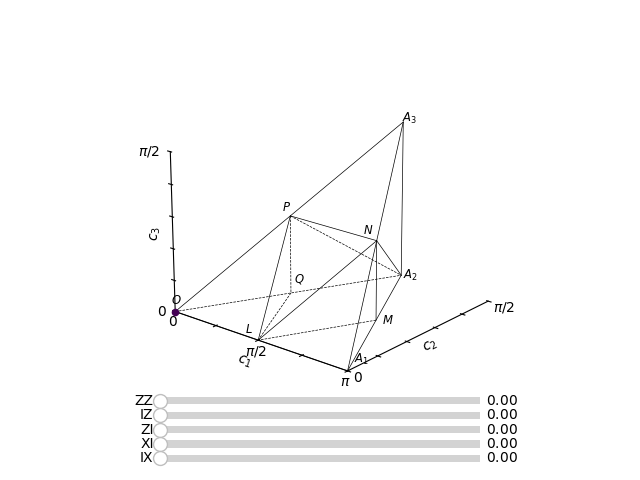

In [3]:
fig = plt.figure()

# initialize the prameter vector
g_vector = [0, 0, 0, 0, 0]
num_params = len(g_vector)

# Create the #3D subplot
ax1 = fig.add_subplot(111, projection="3d")
fig.subplots_adjust(bottom=0.15)

# iniital rendering
w = WeylChamber()
w.render(ax1)

# capture the background
background = fig.canvas.copy_from_bbox(ax1.bbox)

# global var to store the scatter plot artists
# NOTE, I think this is needed to
# keep all interactive components responsive and not garbage collected
scatter_plots = []


def update(val, idx):
    global scatter_plots
    g_vector[idx] = val

    # only going to plot a single point at a time
    while scatter_plots:
        scatter = scatter_plots.pop()
        scatter.remove()

    H = ZZ_ParallelDrive(*g_vector)
    U = H.to_unitary(t=1)
    color = H.color
    c1, c2, c3 = c1c2c3(U)
    if c1 > 0.5:
        c1 = 1 - c1

    # create a new scatter plot
    scatter = ax1.scatter3D(c1, c2, c3, **{"color": color})
    scatter_plots.append(scatter)

    fig.canvas.restore_region(background)
    ax1.draw_artist(scatter)
    # fig.canvas.blit(ax1.bbox)
    fig.canvas.draw_idle()


# crete sliders
sliders = []
for idx in range(num_params):
    ax_slider = fig.add_axes([0.25, 0.15 - 0.03 * idx, 0.5, 0.03])
    gamma_slider = Slider(
        ax_slider,
        label=ZZ_ParallelDrive.g_labels[idx],
        valmin=0,
        valmax=np.pi / 2,
        valinit=0,
    )
    gamma_slider.on_changed(lambda val, idx=idx: update(val, idx))
    sliders.append(gamma_slider)

update(0, 0)
plt.show()

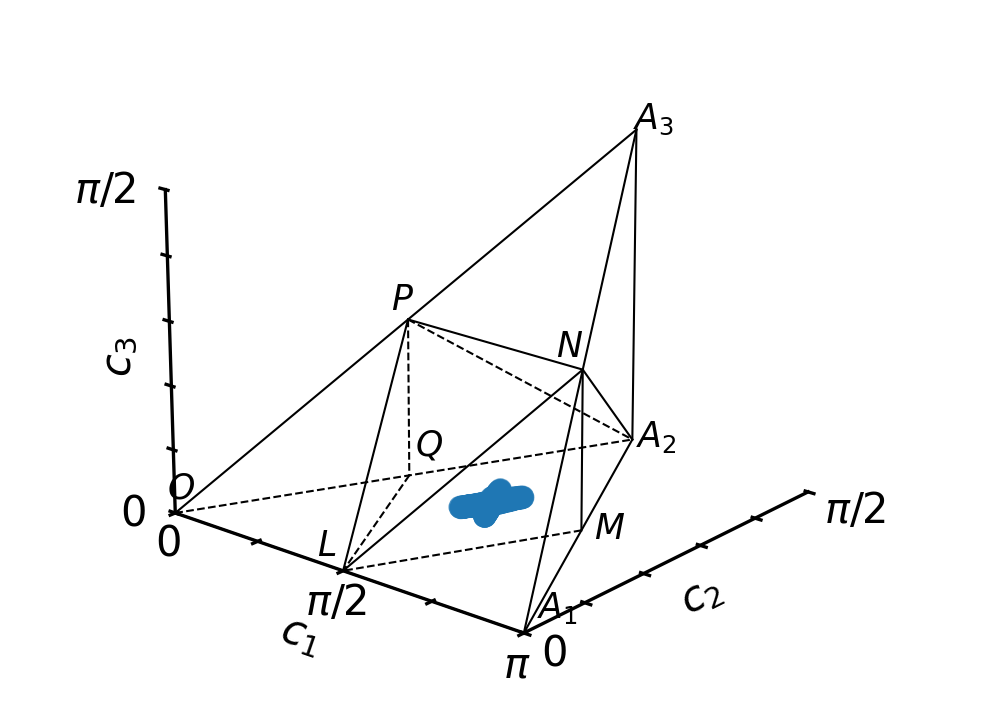

In [9]:
from numpy.random import random

rand_pd_basis_gate = lambda: ZZ_ParallelDrive(
    g_zz=3 * np.pi / 4,
    g_ix=(np.pi**2 / 5) + (random() * 0.5 - 0.25),
    g_xi=(np.pi**2 / 5) + (random() * 0.5 - 0.25),
    g_zi=(random() * np.pi / 2 - np.pi / 4),
    g_iz=(random() * np.pi / 2 - np.pi / 4),
).to_unitary()

w = WeylChamber()
for _ in range(N := 1_000):
    w.add_point(*c1c2c3(rand_pd_basis_gate()))
w.plot()

In [8]:
# from monodromy.coordinates import (
#     monodromy_to_positive_canonical_coordinate,
#     positive_canonical_to_monodromy_coordinate,
#     positive_to_balanced_canonical_coordinate
# )

# fig = plt.figure()

# # initialize the prameter vector
# g_vector = [0, 0, 0]
# num_params = len(g_vector)

# # Create the #3D subplot
# ax1 = fig.add_subplot(111, projection="3d", computed_zorder=False)
# fig.subplots_adjust(bottom=0.15)

# # iniital rendering
# w = WeylChamber()
# w.render(ax1)

# # capture the background
# background = fig.canvas.copy_from_bbox(ax1.bbox)

# # global var to store the scatter plot artists
# # NOTE, I think this is needed to
# # keep all interactive components responsive and not garbage collected
# scatter_plots = []


# def update(val, idx):
#     global scatter_plots
#     g_vector[idx] = val

#     # only going to plot a single point at a time
#     while scatter_plots:
#         scatter = scatter_plots.pop()
#         scatter.remove()

#     c1, c2, c3 = g_vector
#     if c1 > 0.5:
#         c1 = 1 - c1

#     mono = positive_canonical_to_monodromy_coordinate(c1, c2, c3)
#     d = -sum(mono)
#     transf = (mono[2] + 1 / 2, d + 1 / 2, mono[0] - 1 / 2, mono[1] - 1 / 2)[:-1]
#     convert_back = np.array(monodromy_to_positive_canonical_coordinate(*transf)) / (
#         np.pi / 2
#     )


#     # create a new scatter plot
#     scatter = ax1.scatter3D(c1, c2, c3, **{"color": "blue"}, zorder=-1)
#     scatter2 = ax1.scatter3D(*convert_back, **{"color": "red"}, zorder=-1)
#     scatter_plots.append(scatter)
#     scatter_plots.append(scatter2)

#     fig.canvas.restore_region(background)
#     ax1.draw_artist(scatter)
#     ax1.draw_artist(scatter2)
#     # fig.canvas.blit(ax1.bbox)
#     fig.canvas.draw_idle()


# # crete sliders
# sliders = []
# for idx in range(num_params):
#     ax_slider = fig.add_axes([0.25, 0.15 - 0.03 * idx, 0.5, 0.03])
#     gamma_slider = Slider(
#         ax_slider,
#         label="abc"[idx],
#         valmin=0,
#         valmax=[
#             1,
#             0.5,
#             0.5,
#         ][idx],
#         valinit=0,
#     )
#     gamma_slider.on_changed(lambda val, idx=idx: update(val, idx))
#     sliders.append(gamma_slider)

# update(0, 0)
# plt.show()